In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from getpass import getpass
from urllib.parse import quote_plus
from sqlalchemy import create_engine, text

senha = quote_plus(getpass("Senha do RDS: "))
host = "demand-forecast-db.cbk6cgk8kt1u.us-east-2.rds.amazonaws.com"
engine = create_engine(f"postgresql+psycopg2://postgres:{senha}@{host}:5432/postgres")

def q(sql):
    return pd.read_sql(text(sql), engine)

plt.rcParams["figure.figsize"] = (10, 4)

Senha do RDS:  ········


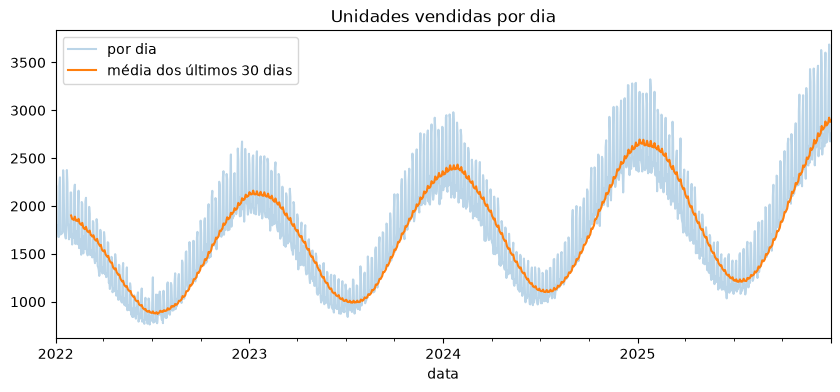

In [4]:
diario = q("""
    SELECT data, SUM(quantidade_vendida) AS unidades
    FROM vendas GROUP BY data ORDER BY data
""")
diario["data"] = pd.to_datetime(diario["data"])
diario = diario.set_index("data")
diario["unidades"] = diario["unidades"].astype(float)
diario["media_movel_30d"] = diario["unidades"].rolling(30).mean()

ax = diario["unidades"].plot(alpha=0.3, label="por dia")
diario["media_movel_30d"].plot(ax=ax, label="média dos últimos 30 dias")
ax.set_title("Unidades vendidas por dia")
ax.legend()
plt.show()

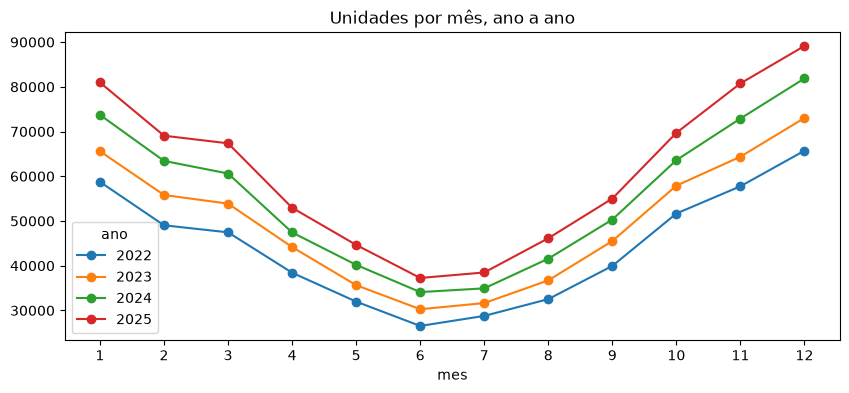

In [5]:
mensal = q("""
    SELECT EXTRACT(YEAR FROM data)::int AS ano,
           EXTRACT(MONTH FROM data)::int AS mes,
           SUM(quantidade_vendida) AS unidades
    FROM vendas GROUP BY 1, 2 ORDER BY 1, 2
""")
tabela = mensal.pivot(index="mes", columns="ano", values="unidades").astype(float)
tabela.plot(marker="o", title="Unidades por mês, ano a ano")
plt.xticks(range(1, 13))
plt.show()

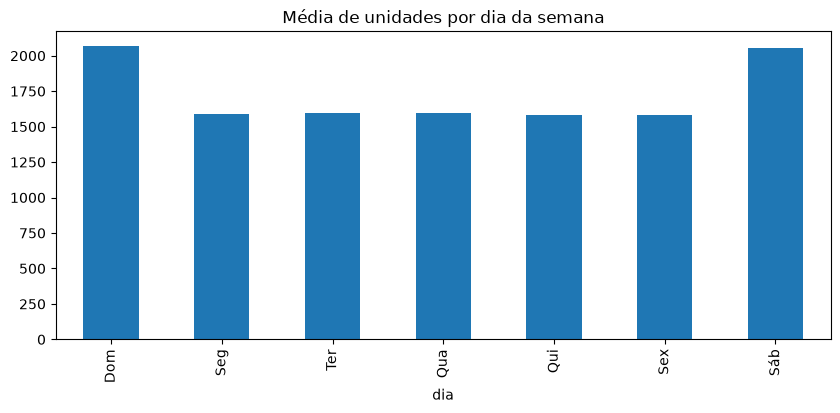

In [6]:
semana = q("""
    SELECT EXTRACT(DOW FROM data)::int AS dow, AVG(unidades_dia) AS media
    FROM (
        SELECT data, SUM(quantidade_vendida) AS unidades_dia
        FROM vendas GROUP BY data
    ) t
    GROUP BY 1 ORDER BY 1
""")
semana["media"] = semana["media"].astype(float)
semana["dia"] = semana["dow"].map({0: "Dom", 1: "Seg", 2: "Ter", 3: "Qua", 4: "Qui", 5: "Sex", 6: "Sáb"})
semana.plot.bar(x="dia", y="media", legend=False, title="Média de unidades por dia da semana")
plt.show()

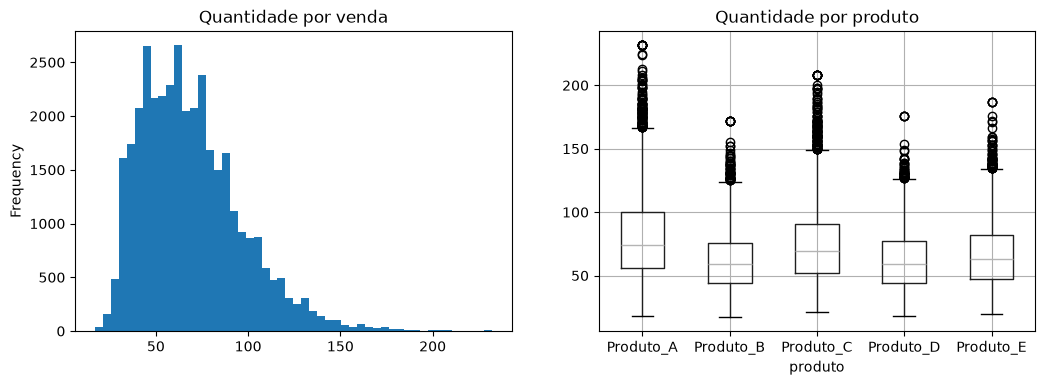

,count,mean,std,min,25%,50%,75%,max
produto,,,,,,,,
Produto_A,7305.0,80.1,32.4,18.0,56.0,74.0,100.0,232.0
Produto_B,7305.0,61.8,22.3,17.0,44.0,59.0,76.0,172.0
Produto_C,7305.0,74.1,29.2,21.0,52.0,69.0,91.0,208.0
Produto_D,7305.0,62.1,22.4,18.0,44.0,59.0,77.0,176.0
Produto_E,7305.0,66.7,24.6,20.0,47.0,63.0,82.0,187.0


In [7]:
linhas = q("""
    SELECT p.nome AS produto, v.quantidade_vendida
    FROM vendas v
    JOIN produtos p ON p.id_produto = v.id_produto
""")

fig, eixos = plt.subplots(1, 2, figsize=(12, 4))
linhas["quantidade_vendida"].plot.hist(bins=50, ax=eixos[0], title="Quantidade por venda")
linhas.boxplot(column="quantidade_vendida", by="produto", ax=eixos[1])
eixos[1].set_title("Quantidade por produto")
plt.suptitle("")
plt.show()

linhas.groupby("produto")["quantidade_vendida"].describe().round(1)

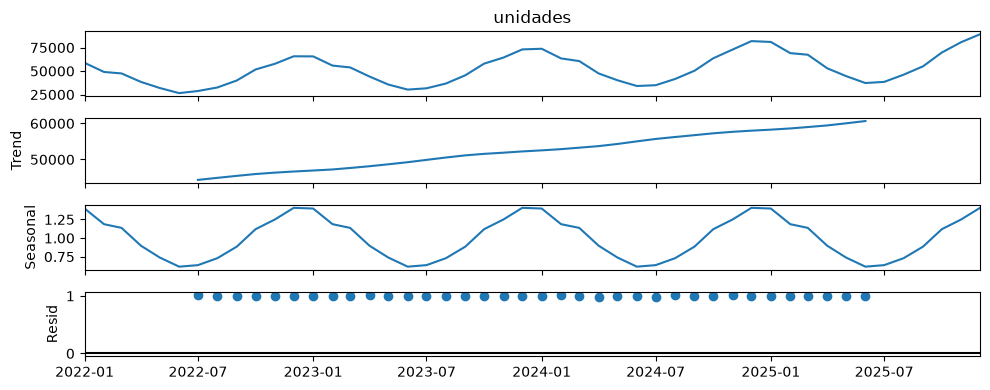

In [8]:
from statsmodels.tsa.seasonal import seasonal_decompose

serie = q("""
    SELECT DATE_TRUNC('month', data)::date AS mes, SUM(quantidade_vendida) AS unidades
    FROM vendas GROUP BY 1 ORDER BY 1
""")
serie["mes"] = pd.to_datetime(serie["mes"])
serie = serie.set_index("mes")["unidades"].astype(float)

resultado = seasonal_decompose(serie, model="multiplicative", period=12)
resultado.plot()
plt.show()

In [9]:
anual = q("""
    SELECT EXTRACT(YEAR FROM data)::int AS ano,
           SUM(quantidade_vendida) AS unidades,
           ROUND(SUM(receita), 2) AS receita
    FROM vendas GROUP BY 1 ORDER BY 1
""")
anual["receita"] = anual["receita"].astype(float)
anual["crescimento_pct"] = (anual["unidades"].pct_change() * 100).round(1)
anual

,ano,unidades,receita,crescimento_pct
0,2022,528604,72357095.72,NaN
1,2023,594583,80792032.16,12.5
2,2024,664720,89893688.01,11.8
3,2025,731536,98520396.80,10.1
